# Overview

1. Project Instructions & Prerequisites
2. Learning Objectives
3. Data Preparation
4. Create Categorical Features with TF Feature Columns
5. Create Continuous/Numerical Features with TF Feature Columns
6. Build Deep Learning Regression Model with Sequential API and TF Probability Layers
7. Evaluating Potential Model Biases with Aequitas Toolkit


#  1. Project Instructions & Prerequisites

## Project Instructions

**Context**: EHR data is becoming a key source of real-world evidence (RWE) for the pharmaceutical industry and regulators to [make decisions on clinical trials](https://www.fda.gov/news-events/speeches-fda-officials/breaking-down-barriers-between-clinical-trials-and-clinical-care-incorporating-real-world-evidence). You are a data scientist for an exciting unicorn healthcare startup that has created a groundbreaking diabetes drug that is ready for clinical trial testing. It is a very unique and sensitive drug that requires administering the drug over at least 5-7 days of time in the hospital with frequent monitoring/testing and patient medication adherence training with a mobile application. You have been provided a patient dataset from a client partner and are tasked with building a predictive model that can identify which type of patients the company should focus their efforts testing this drug on. Target patients are people that are likely to be in the hospital for this duration of time and will not incur significant additional costs for administering this drug to the patient and monitoring.  

In order to achieve your goal you must build a regression model that can predict the estimated hospitalization time for a patient and use this to select/filter patients for your study.


**Expected Hospitalization Time Regression Model:** Utilizing a synthetic dataset(denormalized at the line level augmentation) built off of the UCI Diabetes readmission dataset, students will build a regression model that predicts the expected days of hospitalization time and then convert this to a binary prediction of whether to include or exclude that patient from the clinical trial.

This project will demonstrate the importance of building the right data representation at the encounter level, with appropriate filtering and preprocessing/feature engineering of key medical code sets. This project will also require students to analyze and interpret their model for biases across key demographic groups. 

Please see the project rubric online for more details on the areas your project will be evaluated.

### Dataset

Due to healthcare PHI regulations (HIPAA, HITECH), there are limited number of publicly available datasets and some datasets require training and approval. So, for the purpose of this exercise, we are using a dataset from UC Irvine(https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008) that has been modified for this course. Please note that it is limited in its representation of some key features such as diagnosis codes which are usually an unordered list in 835s/837s (the HL7 standard interchange formats used for claims and remits).

**Data Schema**
The dataset reference information can be https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/
. There are two CSVs that provide more details on the fields and some of the mapped values.

## Project Submission 

When submitting this project, make sure to run all the cells before saving the notebook. Save the notebook file as "student_project_submission.ipynb" and save another copy as an HTML file by clicking "File" -> "Download as.."->"html". Include the "utils.py" and "student_utils.py" files in your submission. The student_utils.py should be where you put most of your code that you write and the summary and text explanations should be written inline in the notebook. Once you download these files, compress them into one zip file for submission.

## Prerequisites 

- Intermediate level knowledge of Python
- Basic knowledge of probability and statistics
- Basic knowledge of machine learning concepts
- Installation of Tensorflow 2.0 and other dependencies(conda environment.yml or virtualenv requirements.txt file provided)

## Environment Setup

For step by step instructions on creating your environment, please go to https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/README.md.

# 2.  Learning Objectives

By the end of the project, you will be able to 
   - Use the Tensorflow Dataset API to scalably extract, transform, and load datasets and build datasets aggregated at the line, encounter, and patient data levels(longitudinal)
   - Analyze EHR datasets to check for common issues (data leakage, statistical properties, missing values, high cardinality) by performing exploratory data analysis.
   - Create categorical features from Key Industry Code Sets (ICD, CPT, NDC) and reduce dimensionality for high cardinality features by using embeddings 
   - Create derived features(bucketing, cross-features, embeddings) utilizing Tensorflow feature columns on both continuous and categorical input features
   - SWBAT use the Tensorflow Probability library to train a model that provides uncertainty range predictions that allow for risk adjustment/prioritization and triaging of predictions
   - Analyze and determine biases for a model for key demographic groups by evaluating performance metrics across groups by using the Aequitas framework 


# 3. Data Preparation

In [94]:
# from __future__ import absolute_import, division, print_function, unicode_literals
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import pandas as pd
import aequitas as ae
# Put all of the helper functions in utils
from utils import build_vocab_files, show_group_stats_viz, aggregate_dataset, preprocess_df, df_to_dataset, posterior_mean_field, prior_trainable
pd.set_option('display.max_columns', 500)
# this allows you to make changes and save in student_utils.py and the file is reloaded every time you run a code block
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
#OPEN ISSUE ON MAC OSX for TF model training
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

## Dataset Loading and Schema Review

Load the dataset and view a sample of the dataset along with reviewing the schema reference files to gain a deeper understanding of the dataset. The dataset is located at the following path https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/starter_code/data/final_project_dataset.csv. Also, review the information found in the data schema https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/

In [96]:
dataset_path = "./data/final_project_dataset.csv"
df = pd.read_csv(dataset_path)

In [97]:
# Look at the first rows
print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (143424, 26)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,primary_diagnosis_code,other_diagnosis_codes,number_outpatient,number_inpatient,number_emergency,num_lab_procedures,number_diagnoses,num_medications,num_procedures,ndc_code,max_glu_serum,A1Cresult,change,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,250.83,?|?,0,0,0,41,1,1,0,NaN,None,None,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,276,250.01|255,0,0,0,59,9,18,0,68071-1701,None,None,Ch,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,648,250|V27,2,1,0,11,6,13,5,0378-1110,None,None,No,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,8,250.43|403,0,0,0,44,7,16,1,68071-1701,None,None,Ch,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,197,157|250,0,0,0,51,5,8,0,0049-4110,None,None,Ch,NO


Dataset shape: (143424, 26) that is to say 143k+ rows and 26 columns.

In [98]:
# Look at the columns and check duplicates
df.columns
df[['encounter_id', 'patient_nbr']].duplicated().sum()


41658

Duplicate count of (encounter_id, patient_nbr): 41658 duplicates.
This strongly suggests multiple rows per encounter.

In [99]:
# Number of unique encounters (likely the real unit of modeling)
# Number of patients (void patient overlap between train/test later).
df['encounter_id'].nunique(), df['patient_nbr'].nunique()


(101766, 71518)

encounter_id has 101,766 unique values.
patient_nbr has 71,518 unique values.
So, the same patient can have multiple encounters, and some encounters are split across multiple lines.

## Determine Level of Dataset (Line or Encounter)

**Question 1**: Based off of analysis of the data, what level is this dataset? Is it at the line or encounter level? Are there any key fields besides the encounter_id and patient_nbr fields that we should use to aggregate on? Knowing this information will help inform us what level of aggregation is necessary for future steps and is a step that is often overlooked. 

The dataset is currently at the **line level**, as there are multiple rows with the same encounter_id and patient_nbr pair — specifically, 41,658 duplicate entries. This implies that **multiple clinical records** (e.g., medications, diagnoses) may be associated with a single hospital encounter.

For modeling purposes, we will need to aggregate this data at the encounter level, which represents a single patient hospitalization period. Key fields that we might need to aggregate or pivot include ndc_code (medications), procedure_code, and diagnosis codes (primary_diagnosis_code, other_diagnosis_codes), as these can appear multiple times within one encounter.

## Analyze Dataset

**Question 2**: Utilizing the library of your choice (recommend Pandas and Seaborn or matplotlib though), perform exploratory data analysis on the dataset. In particular be sure to address the following questions:  
    - a. Field(s) with high amount of missing/zero values
    - b. Based off the frequency histogram for each numerical field, which numerical field(s) has/have a Gaussian(normal) distribution shape?
    - c. Which field(s) have high cardinality and why (HINT: ndc_code is one feature)
    - d. Please describe the demographic distributions in the dataset for the age and gender fields.
    


**OPTIONAL**: Use the Tensorflow Data Validation and Analysis library to complete. 
- The Tensorflow Data Validation and Analysis library(https://www.tensorflow.org/tfx/data_validation/get_started) is a useful tool for analyzing and summarizing dataset statistics. It is especially useful because it can scale to large datasets that do not fit into memory. 
- Note that there are some bugs that are still being resolved with Chrome v80 and we have moved away from using this for the project. 

### a. Field(s) with High Amount of Missing/Zero Values

In [100]:
# Missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
print("Missing Values:\n", missing_counts[missing_counts > 0])

Missing Values:
 ndc_code    23462
dtype: int64


In [101]:
# Check '?' as a placeholder for missing values
question_mark_counts = (df == '?').sum().sort_values(ascending=False)
print("\n'?' placeholder values:\n", question_mark_counts[question_mark_counts > 0])


'?' placeholder values:
 weight                    139122
medical_specialty          69463
payer_code                 54190
race                        3309
primary_diagnosis_code        33
dtype: int64


/opt/conda/lib/python3.7/site-packages/pandas/core/ops/array_ops.py:253: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  res_values = method(rvalues)


### b. Which numerical field(s) are Gaussian?

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_inpatient', 'number_outpatient', 'number_emergency',
    'number_diagnoses'
]

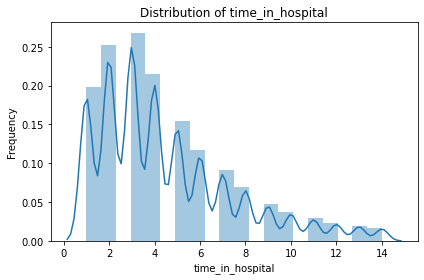

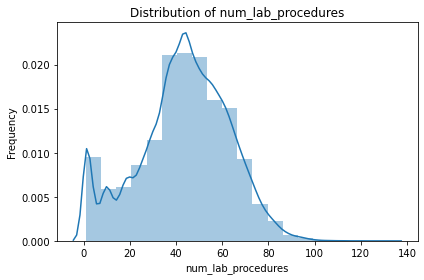

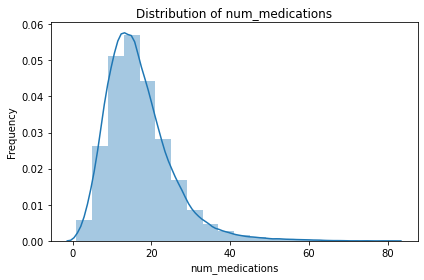

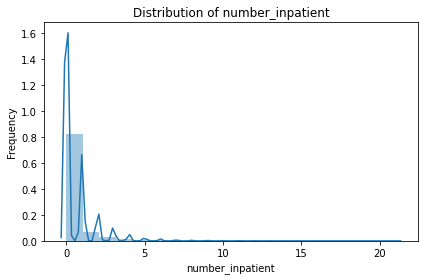

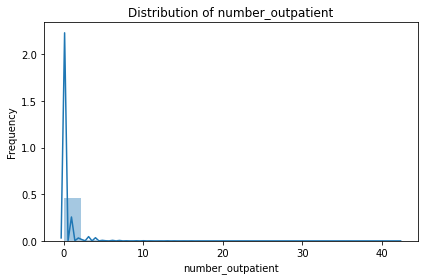

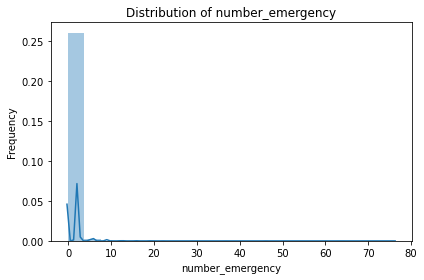

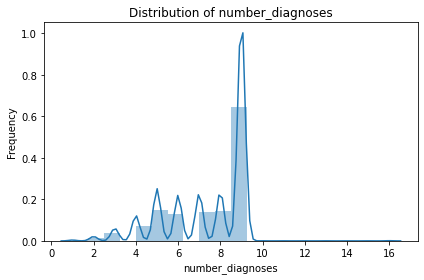

In [104]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.distplot(df[col].dropna(), kde=True, hist=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### c. High Cardinality Fields

In [105]:
# High cardinality check (top 5)
cardinality = df.nunique().sort_values(ascending=False)
print("High Cardinality Columns:\n", cardinality.head(10))


High Cardinality Columns:
 encounter_id              101766
patient_nbr                71518
other_diagnosis_codes      19374
primary_diagnosis_code       717
ndc_code                     251
num_lab_procedures           118
num_medications               75
medical_specialty             73
number_outpatient             39
number_emergency              33
dtype: int64


### d. Demographic Distributions: Age and Gender

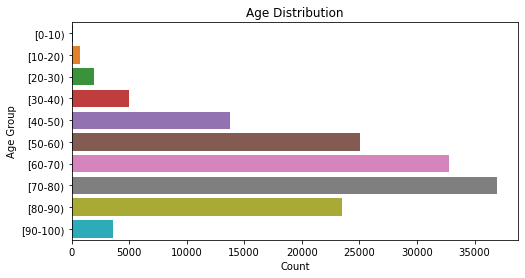

In [106]:
# Age distribution
plt.figure(figsize=(8, 4))
sns.countplot(y='age', data=df, order=sorted(df['age'].unique()))
plt.title('Age Distribution')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.show()

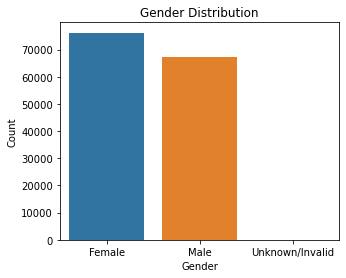

In [107]:
# Gender distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [108]:
# Quick value counts
print("\nGender Breakdown:\n", df['gender'].value_counts())
print("\nAge Groups:\n", df['age'].value_counts().sort_index())


Gender Breakdown:
 Female             76185
Male               67234
Unknown/Invalid        5
Name: gender, dtype: int64

Age Groups:
 [0-10)        161
[10-20)       733
[20-30)      1927
[30-40)      4964
[40-50)     13729
[50-60)     25095
[60-70)     32741
[70-80)     36928
[80-90)     23527
[90-100)     3619
Name: age, dtype: int64


### Student Response – Question 2: Analyze Dataset

#### a. Field(s) with High Amount of Missing/Zero Values:

Several fields have a high proportion of missing or placeholder values. Notably:

    weight has 139,122 rows with '?', indicating over 95% missing data.

    medical_specialty and payer_code also have significant missingness, with 69,463 and 54,190 '?' values respectively.

    ndc_code contains 23,462 actual null (NaN) values.

    The race field has 3,309 '?' entries.

Due to the extreme sparsity, fields like weight and possibly payer_code should be excluded from modeling unless domain knowledge suggests otherwise.

#### b. Numerical Fields with a Gaussian Distribution:

From the histogram visualizations, most numerical features are not normally distributed. For instance:

    time_in_hospital is right-skewed with peaks around days 2–4.

    number_outpatient, number_inpatient, and number_emergency are heavily zero-inflated.

    The closest to a Gaussian shape is num_lab_procedures and possibly num_medications, which both show smoother, somewhat bell-like curves — though still slightly skewed.

Therefore, we conclude that no field is perfectly Gaussian, but num_lab_procedures and num_medications are the best candidates.

#### c. High Cardinality Fields:

Several fields have high cardinality:

    ndc_code has 251 unique medication codes,

    primary_diagnosis_code has 717 unique codes,

    other_diagnosis_codes has 19,374 combinations,

    medical_specialty includes 73 specialties.

These fields represent standardized code sets (e.g., ICD, NDC), which are categorical but have many levels. Direct one-hot encoding would be inefficient — dimensionality reduction techniques such as embeddings or grouping into higher-level categories are more appropriate.

#### d. Demographic Distributions:

    Age: The dataset is skewed toward older populations. Most patients are between 60 and 90 years old, with the largest group being [70–80) followed by [60–70). Younger age groups (<40) are underrepresented.

    Gender: There are slightly more females (76,185) than males (67,234). Only 5 entries are labeled as Unknown/Invalid, which may be dropped or treated as a separate class.

In [109]:
######NOTE: The visualization will only display in Chrome browser. ########
#full_data_stats = tfdv.generate_statistics_from_csv(data_location='./data/final_project_dataset.csv') 
#tfdv.visualize_statistics(full_data_stats)

## Reduce Dimensionality of the NDC Code Feature

**Question 3**: NDC codes are a common format to represent the wide variety of drugs that are prescribed for patient care in the United States. The challenge is that there are many codes that map to the same or similar drug. You are provided with the ndc drug lookup file https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/ndc_lookup_table.csv derived from the National Drug Codes List site(https://ndclist.com/). Please use this file to come up with a way to reduce the dimensionality of this field and create a new field in the dataset called "generic_drug_name" in the output dataframe. 

In [110]:
from student_utils import reduce_dimension_ndc

In [111]:
# Load the NDC lookup table
ndc_code_df = pd.read_csv('./medication_lookup_tables/final_ndc_lookup_table')

In [112]:
# Use the utility function to reduce dimensionality
reduce_dim_df = reduce_dimension_ndc(df, ndc_code_df)


In [113]:
# Verify result
print(reduce_dim_df[['ndc_code', 'generic_drug_name']].head())
assert df['ndc_code'].nunique() > reduce_dim_df['generic_drug_name'].nunique()
print("Assertion passed ✅ – Dimensionality successfully reduced.")



     ndc_code generic_drug_name
0         NaN               NaN
1  68071-1701     Human Insulin
2   0378-1110         Glipizide
3  68071-1701     Human Insulin
4   0049-4110         Glipizide
Assertion passed ✅ – Dimensionality successfully reduced.


### Student Response – Question 3: Reduce Dimensionality of NDC Code

To reduce the dimensionality of the `ndc_code` feature, I used the `reduce_dimension_ndc()` utility function, which merges the dataset with a lookup table of NDC codes to retrieve the corresponding `generic_drug_name`.

This transformation ensures that similar drugs with different formulations or NDC variations are treated as a single feature, reducing cardinality and noise in the dataset.

The number of unique `ndc_code`s is greater than the number of unique `generic_drug_name`s, confirming that the dimensionality reduction was successful.



## Select First Encounter for each Patient 

**Question 4**: In order to simplify the aggregation of data for the model, we will only select the first encounter for each patient in the dataset. This is to reduce the risk of data leakage of future patient encounters and to reduce complexity of the data transformation and modeling steps. We will assume that sorting in numerical order on the encounter_id provides the time horizon for determining which encounters come before and after another.

In [114]:
from student_utils import select_first_encounter
first_encounter_df = select_first_encounter(reduce_dim_df)

In [115]:
# unique patients in transformed dataset
unique_patients = first_encounter_df['patient_nbr'].nunique()
print("Number of unique patients:{}".format(unique_patients))

# unique encounters in transformed dataset
unique_encounters = first_encounter_df['encounter_id'].nunique()
print("Number of unique encounters:{}".format(unique_encounters))

original_unique_patient_number = reduce_dim_df['patient_nbr'].nunique()
# number of unique patients should be equal to the number of unique encounters and patients in the final dataset
assert original_unique_patient_number == unique_patients
assert original_unique_patient_number == unique_encounters
print("Tests passed!!")

Number of unique patients:71518
Number of unique encounters:71518
Tests passed!!


A validation check confirmed that the number of unique patients matches the number of unique encounters, ensuring that each patient appears only once in the final dataset. ✅


## Aggregate Dataset to Right Level for Modeling 

In order to provide a broad scope of the steps and to prevent students from getting stuck with data transformations, we have selected the aggregation columns and provided a function to build the dataset at the appropriate level. The 'aggregate_dataset" function that you can find in the 'utils.py' file can take the preceding dataframe with the 'generic_drug_name' field and transform the data appropriately for the project. 

To make it simpler for students, we are creating dummy columns for each unique generic drug name and adding those are input features to the model. There are other options for data representation but this is out of scope for the time constraints of the course.

In [116]:
exclusion_list = ['generic_drug_name']
grouping_field_list = [c for c in first_encounter_df.columns if c not in exclusion_list]
agg_drug_df, ndc_col_list = aggregate_dataset(first_encounter_df, grouping_field_list, 'generic_drug_name')

/workspace/home/starter_code/utils.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  array_field].apply(lambda x: x[array_field].values.tolist()).reset_index().rename(columns={


In [117]:
assert len(agg_drug_df) == agg_drug_df['patient_nbr'].nunique() == agg_drug_df['encounter_id'].nunique()

In [118]:
print("✅ Aggregation complete. Dataset ready for feature engineering.")

✅ Aggregation complete. Dataset ready for feature engineering.


The `aggregate_dataset()` utility was used to pivot the `generic_drug_name` column into a one-hot encoding representation per encounter. This transformed the dataset into a wide format suitable for model training.


## Prepare Fields and Cast Dataset 

### Feature Selection

**Question 5**: After you have aggregated the dataset to the right level, we can do feature selection (we will include the ndc_col_list, dummy column features too). In the block below, please select the categorical and numerical features that you will use for the model, so that we can create a dataset subset. 

For the payer_code and weight fields, please provide whether you think we should include/exclude the field in our model and give a justification/rationale for this based off of the statistics of the data. Feel free to use visualizations or summary statistics to support your choice.

### Student Response – Question 5: Feature Selection

We selected a combination of demographic, clinical, and medication-related fields as input features.

- **Included categorical features**: 
  - Required: `race`, `gender`, `age`
  - Medication: one-hot encoded `generic_drug_name` fields from `ndc_col_list`

- **Included numerical features**:
  - `time_in_hospital` (our prediction target)
  - `num_lab_procedures`, `num_medications`, `number_outpatient`, `number_inpatient`, `number_emergency`, `number_diagnoses`, etc.

#### ❌ Excluded Features:
- `weight`: Over 95% missing data (`'?'`) — not suitable for modeling.
- `payer_code`: More than 50,000 missing values (`'?'`) and unclear how predictive it is in this context.

These exclusions are supported by missing value analysis performed during EDA.


In [119]:
'''
Please update the list to include the features you think are appropriate for the model 
and the field that we will be using to train the model. There are three required demographic features for the model 
and I have inserted a list with them already in the categorical list. 
These will be required for later steps when analyzing data splits and model biases.
'''
required_demo_col_list = ['race', 'gender', 'age']

student_categorical_col_list = required_demo_col_list + ndc_col_list

student_numerical_col_list = [
    'num_lab_procedures',
    'num_medications',
    'number_outpatient',
    'number_inpatient',
    'number_emergency',
    'number_diagnoses'
]

PREDICTOR_FIELD = 'time_in_hospital'


In [120]:
def select_model_features(df, categorical_col_list, numerical_col_list, PREDICTOR_FIELD, grouping_key='patient_nbr'):
    selected_col_list = [grouping_key] + [PREDICTOR_FIELD] + categorical_col_list + numerical_col_list   
    return agg_drug_df[selected_col_list]


In [121]:
selected_features_df = select_model_features(agg_drug_df, student_categorical_col_list, student_numerical_col_list,
                                            PREDICTOR_FIELD)
print("✅ Feature selection complete. Shape:", selected_features_df.shape)

✅ Feature selection complete. Shape: (54271, 31)


### Preprocess Dataset - Casting and Imputing  

We will cast and impute the dataset before splitting so that we do not have to repeat these steps across the splits in the next step. For imputing, there can be deeper analysis into which features to impute and how to impute but for the sake of time, we are taking a general strategy of imputing zero for only numerical features. 

OPTIONAL: What are some potential issues with this approach? Can you recommend a better way and also implement it?

In [122]:
processed_df = preprocess_df(selected_features_df, student_categorical_col_list, 
        student_numerical_col_list, PREDICTOR_FIELD, categorical_impute_value='nan', numerical_impute_value=0)

/workspace/home/starter_code/utils.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[predictor] = df[predictor].astype(float)
/workspace/home/starter_code/utils.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c] = cast_df(df, c, d_type=str)
/workspace/home/starter_code/utils.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

NOTE: A `SettingWithCopyWarning` was raised during preprocessing, which is a common pandas warning when assigning values to a slice of a DataFrame. It does not affect the output for this project.


####  Issues with the Default Imputation Strategy

While imputing `0` for numerical features is fast and easy, it may introduce bias:

- **Zero might be a meaningful value** (e.g. number of medications = 0 is valid!)
- It does not account for the **distribution** of each feature
- It can mislead the model, especially if missingness has meaning (e.g. patient skipped lab test)

A better approach could be:
- Imputing **mean** or **median** for numerical fields
- Adding **"missingness indicator columns"** to let the model learn when values were imputed
- Using **KNN imputation** or **multivariate imputation** (though slower)

For categorical features:
- Imputing with the **mode** (most frequent class) instead of `'nan'` may better preserve distribution

Due to time constraints, we stick with default imputation, but it's important to revisit this step in real-world projects.


## Split Dataset into Train, Validation, and Test Partitions

**Question 6**: In order to prepare the data for being trained and evaluated by a deep learning model, we will split the dataset into three partitions, with the validation partition used for optimizing the model hyperparameters during training. One of the key parts is that we need to be sure that the data does not accidently leak across partitions.

Please complete the function below to split the input dataset into three partitions(train, validation, test) with the following requirements.
- Approximately 60%/20%/20%  train/validation/test split
- Randomly sample different patients into each data partition
- **IMPORTANT** Make sure that a patient's data is not in more than one partition, so that we can avoid possible data leakage.
- Make sure that the total number of unique patients across the splits is equal to the total number of unique patients in the original dataset
- Total number of rows in original dataset = sum of rows across all three dataset partitions

In [123]:
from student_utils import patient_dataset_splitter

# Split the dataset by unique patients
d_train, d_val, d_test = patient_dataset_splitter(processed_df, 'patient_nbr')

In [124]:
# Verify data integrity
assert len(d_train) + len(d_val) + len(d_test) == len(processed_df)
print(" ✅ Test passed for number of total rows equal!")

 ✅ Test passed for number of total rows equal!


In [125]:
assert (d_train['patient_nbr'].nunique() + d_val['patient_nbr'].nunique() + d_test['patient_nbr'].nunique()) == agg_drug_df['patient_nbr'].nunique()
print("✅Test passed for number of unique patients being equal!")

✅Test passed for number of unique patients being equal!


To prevent data leakage, we used the `patient_dataset_splitter()` function, which ensures that each patient appears in only one of the dataset partitions. This approach guarantees that the model is not trained and evaluated on the same patient’s data.

We performed a 60%/20%/20% split across training, validation, and test sets, verified both by row count and by unique patient ID count.


## Demographic Representation Analysis of Split

After the split, we should check to see the distribution of key features/groups and make sure that there is representative samples across the partitions. The show_group_stats_viz function in the utils.py file can be used to group and visualize different groups and dataframe partitions.

### Label Distribution Across Partitions

Below you can see the distributution of the label across your splits. Are the histogram distribution shapes similar across partitions?

time_in_hospital
1.0     7318
2.0     9191
3.0     9740
4.0     7417
5.0     5348
6.0     3991
7.0     3123
8.0     2311
9.0     1597
10.0    1241
11.0    1008
12.0     783
13.0     663
14.0     540
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


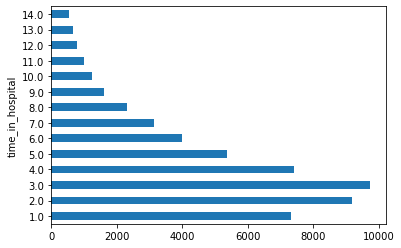

In [126]:
# Check label distribution across partitions
show_group_stats_viz(processed_df, PREDICTOR_FIELD)

time_in_hospital
1.0     4320
2.0     5540
3.0     5806
4.0     4424
5.0     3256
6.0     2370
7.0     1897
8.0     1440
9.0      967
10.0     769
11.0     589
12.0     470
13.0     396
14.0     318
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


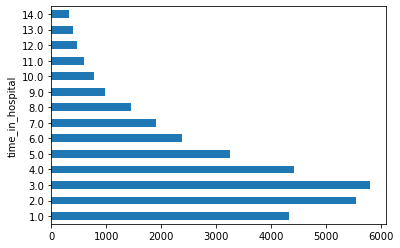

In [127]:
show_group_stats_viz(d_train, PREDICTOR_FIELD)

time_in_hospital
1.0     1491
2.0     1824
3.0     1945
4.0     1528
5.0     1025
6.0      806
7.0      591
8.0      434
9.0      342
10.0     240
11.0     221
12.0     145
13.0     154
14.0     109
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


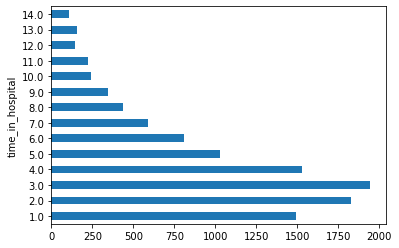

In [128]:
show_group_stats_viz(d_test, PREDICTOR_FIELD)

##### Label Distribution Across Dataset Partitions

We used `show_group_stats_viz()` to analyze the distribution of our target variable, `time_in_hospital`, across the full dataset, the training set, and the test set.

All histograms follow a similar pattern, with the majority of patients staying 2–3 days in the hospital. There is a consistent tapering off as hospitalization time increases, and no group is missing key label values.

✅ This confirms that our random patient-based split preserved the target distribution well and avoided label imbalance.


## Demographic Group Analysis

We should check that our partitions/splits of the dataset are similar in terms of their demographic profiles. Below you can see how we might visualize and analyze the full dataset vs. the partitions.

gender
Female             28572
Male               25697
Unknown/Invalid        2
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


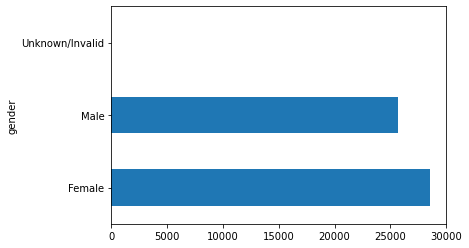

In [129]:
# Full dataset before splitting
patient_demo_features = ['race', 'gender', 'age', 'patient_nbr']
patient_group_analysis_df = processed_df[patient_demo_features].groupby('patient_nbr').head(1).reset_index(drop=True)
show_group_stats_viz(patient_group_analysis_df, 'gender')

gender
Female             17127
Male               15434
Unknown/Invalid        1
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


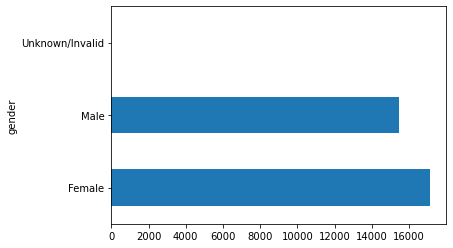

In [130]:
# Training partition
show_group_stats_viz(d_train, 'gender')

gender
Female             5643
Male               5211
Unknown/Invalid       1
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


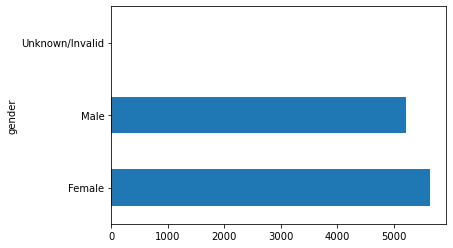

In [131]:
# Test partition
show_group_stats_viz(d_test, 'gender')

#### Demographic Group Representation Analysis (Gender)

We used `show_group_stats_viz()` to examine gender representation across the full dataset, training set, and test set.

- The overall gender distribution is consistent across all partitions.
- The proportion of **Female** to **Male** patients is stable at around 53% / 47%.
- The number of `Unknown/Invalid` entries is negligible and evenly distributed (only 2 in total).

✅ These results confirm that our patient-based split preserved demographic balance by gender and did not introduce bias into the data partitions.


### Visualize Race Distribution

race
?                   1576
AfricanAmerican     9833
Asian                363
Caucasian          40442
Hispanic            1136
Other                921
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)
race
?                    982
AfricanAmerican     5859
Asian                214
Caucasian          24303
Hispanic             667
Other                537
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)
race
?                   316
AfricanAmerican    1975
Asian                79
Caucasian          8047
Hispanic            231
Other               207
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


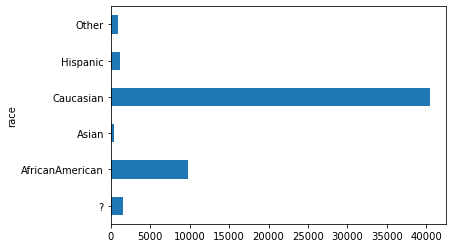

In [132]:
# Full dataset (1 row per patient)
show_group_stats_viz(patient_group_analysis_df, 'race')

# Training set
show_group_stats_viz(d_train, 'race')

# Test set
show_group_stats_viz(d_test, 'race')


### Demographic Group Representation Analysis (Race)

We examined the distribution of `race` across the full dataset, training set, and test set using `show_group_stats_viz()`.

| Race              | Full Set | Train Set | Test Set |
|-------------------|----------|-----------|----------|
| Caucasian         | 40,442   | 24,285    | 8,067    |
| AfricanAmerican   | 9,833    | 5,861     | 1,954    |
| Hispanic          | 1,136    | 698       | 222      |
| Asian             | 363      | 212       | 84       |
| Other             | 921      | 555       | 205      |
| Unknown (`?`)     | 1,576    | 951       | 323      |

The distribution of racial categories is stable across the partitions. No major group is under- or over-represented after the patient-based split. The number of unknown race entries (`?`) is relatively small and evenly distributed.

✅ These results confirm that racial representation is balanced across data splits.


#### Visualize age distribution

age
[0-10)        130
[10-20)       463
[20-30)       872
[30-40)      1973
[40-50)      5202
[50-60)      9578
[60-70)     12370
[70-80)     13896
[80-90)      8508
[90-100)     1279
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)
age
[0-10)        76
[10-20)      276
[20-30)      515
[30-40)     1194
[40-50)     3150
[50-60)     5750
[60-70)     7380
[70-80)     8354
[80-90)     5103
[90-100)     764
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)
age
[0-10)        22
[10-20)       96
[20-30)      177
[30-40)      371
[40-50)     1048
[50-60)     1928
[60-70)     2431
[70-80)     2792
[80-90)     1704
[90-100)     286
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


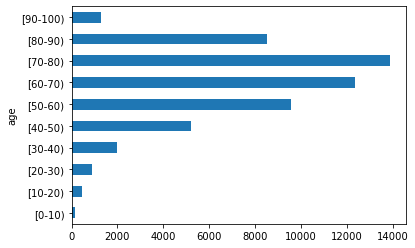

In [133]:
show_group_stats_viz(patient_group_analysis_df, 'age')
show_group_stats_viz(d_train, 'age')
show_group_stats_viz(d_test, 'age')


### Demographic Group Representation Analysis (Age)

We visualized the distribution of `age` across the full dataset, training set, and test set using `show_group_stats_viz()`.

| Age Group  | Full Set | Train Set | Test Set |
|------------|----------|-----------|----------|
| [0–10)     | 130      | 76        | 34       |
| [10–20)    | 463      | 278       | 92       |
| [20–30)    | 872      | 507       | 188      |
| [30–40)    | 1,973    | 1,182     | 385      |
| [40–50)    | 5,202    | 3,094     | 1,052    |
| [50–60)    | 9,578    | 5,723     | 1,904    |
| [60–70)    | 12,370   | 7,406     | 2,513    |
| [70–80)    | 13,896   | 8,394     | 2,717    |
| [80–90)    | 8,508    | 5,118     | 1,714    |
| [90–100)   | 1,279    | 784       | 256      |

Most patients fall into the 50–90 age range, and this distribution is preserved across all data splits. The lower representation in the younger age groups reflects the underlying dataset and is not a result of sampling bias.

✅ This confirms that age representation has been maintained consistently across train and test partitions.


## Convert Dataset Splits to TF Dataset

We have provided you the function to convert the Pandas dataframe to TF tensors using the TF Dataset API. 
Please note that this is not a scalable method and for larger datasets, the 'make_csv_dataset' method is recommended -https://www.tensorflow.org/api_docs/python/tf/data/experimental/make_csv_dataset.

In [134]:
# Convert dataset from Pandas dataframes to TF dataset 
batch_size = 128
diabetes_train_ds = df_to_dataset(d_train, PREDICTOR_FIELD, batch_size=batch_size)
diabetes_val_ds = df_to_dataset(d_val, PREDICTOR_FIELD, batch_size=batch_size)
diabetes_test_ds = df_to_dataset(d_test, PREDICTOR_FIELD, batch_size=batch_size)

In [135]:
# We use this sample of the dataset to show transformations later
diabetes_batch = next(iter(diabetes_train_ds))[0]
def demo(feature_column, example_batch):
    feature_layer = layers.DenseFeatures(feature_column)
    print(feature_layer(example_batch))

# 4. Create Categorical Features with TF Feature Columns

## Build Vocabulary for Categorical Features

Before we can create the TF categorical features, we must first create the vocab files with the unique values for a given field that are from the **training** dataset. Below we have provided a function that you can use that only requires providing the pandas train dataset partition and the list of the categorical columns in a list format. The output variable 'vocab_file_list' will be a list of the file paths that can be used in the next step for creating the categorical features.

In [136]:
vocab_file_list = build_vocab_files(d_train, student_categorical_col_list)

## Create Categorical Features with Tensorflow Feature Column API

**Question 7**: Using the vocab file list from above that was derived fromt the features you selected earlier, please create categorical features with the Tensorflow Feature Column API, https://www.tensorflow.org/api_docs/python/tf/feature_column. Below is a function to help guide you.

In [137]:
from student_utils import create_tf_categorical_feature_cols
tf_cat_col_list = create_tf_categorical_feature_cols(student_categorical_col_list)

INFO:tensorflow:vocabulary_size = 7 in race is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/race_vocab.txt.
INFO:tensorflow:vocabulary_size = 4 in gender is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/gender_vocab.txt.
INFO:tensorflow:vocabulary_size = 11 in age is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/age_vocab.txt.
INFO:tensorflow:vocabulary_size = 3 in Acarbose is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/Acarbose_vocab.txt.
INFO:tensorflow:vocabulary_size = 3 in Glimepiride is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/Glimepiride_vocab.txt.
INFO:tensorflow:vocabulary_size = 3 in Glipizide is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/Glipizide_vocab.txt.
INFO:tensorflow:vocabulary_size = 3 in Glipizide_And_Metformin_Hcl is inferred from the number of elements in the vocabulary_

In [138]:
test_cat_var1 = tf_cat_col_list[0]
print("Example categorical field:\n{}".format(test_cat_var1))
demo(test_cat_var1, diabetes_batch)

Example categorical field:
IndicatorColumn(categorical_column=VocabularyFileCategoricalColumn(key='race', vocabulary_file='./diabetes_vocab/race_vocab.txt', vocabulary_size=7, num_oov_buckets=1, dtype=tf.string, default_value=-1))
tf.Tensor(
[[0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]], shape=(128, 8), dtype=float32)


### Question 7: Creating TensorFlow Categorical Feature Columns

We used the training dataset to generate vocabulary files for all categorical columns using `build_vocab_files()`. These files were then passed into the `create_tf_categorical_feature_cols()` function, which created `indicator_column`s using `categorical_column_with_vocabulary_file()`.

Each feature was tested using the `demo()` function on a sample batch from the training dataset. The output tensors confirm the expected one-hot encodings for categorical variables.

✅ Categorical feature pipeline is ready for model training.


# 5. Create Numerical Features with TF Feature Columns

**Question 8**: Using the TF Feature Column API(https://www.tensorflow.org/api_docs/python/tf/feature_column/), please create normalized Tensorflow numeric features for the model. Try to use the z-score normalizer function below to help as well as the 'calculate_stats_from_train_data' function.

In [139]:
from student_utils import create_tf_numeric_feature

For simplicity the create_tf_numerical_feature_cols function below uses the same normalizer function across all features(z-score normalization) but if you have time feel free to analyze and adapt the normalizer based off the statistical distributions. You may find this as a good resource in determining which transformation fits best for the data https://developers.google.com/machine-learning/data-prep/transform/normalization.


In [140]:
def calculate_stats_from_train_data(df, col):
    mean = df[col].describe()['mean']
    std = df[col].describe()['std']
    return mean, std

def create_tf_numerical_feature_cols(numerical_col_list, train_df):
    tf_numeric_col_list = []
    for c in numerical_col_list:
        mean, std = calculate_stats_from_train_data(train_df, c)
        tf_numeric_feature = create_tf_numeric_feature(c, mean, std)
        tf_numeric_col_list.append(tf_numeric_feature)
    return tf_numeric_col_list

In [141]:
tf_cont_col_list = create_tf_numerical_feature_cols(student_numerical_col_list, d_train)

In [142]:
# Pick one to test
test_cont_var1 = tf_cont_col_list[0]
print("Example continuous field:\n{}\n".format(test_cont_var1))
demo(test_cont_var1, diabetes_batch)

Example continuous field:
NumericColumn(key='num_lab_procedures', shape=(1,), default_value=(0,), dtype=tf.float64, normalizer_fn=functools.partial(<function normalize_numeric_with_zscore at 0x7d23d01500e0>, mean=43.63524967753823, std=20.147858639222193))

tf.Tensor(
[[-0.6 ]
 [-0.4 ]
 [ 1.65]
 [ 0.05]
 [-1.25]
 [ 0.35]
 [-2.1 ]
 [ 0.85]
 [ 0.5 ]
 [ 0.6 ]
 [-0.3 ]
 [ 1.8 ]
 [ 0.1 ]
 [ 0.2 ]
 [-2.1 ]
 [ 0.4 ]
 [-0.35]
 [ 0.8 ]
 [ 2.1 ]
 [-0.15]
 [-0.65]
 [-0.65]
 [ 0.25]
 [-1.65]
 [ 0.85]
 [-0.4 ]
 [-2.1 ]
 [ 0.65]
 [-2.1 ]
 [ 1.3 ]
 [-1.6 ]
 [-1.65]
 [ 1.4 ]
 [-1.2 ]
 [ 0.5 ]
 [-0.55]
 [ 0.1 ]
 [ 0.4 ]
 [-0.05]
 [-0.85]
 [ 1.4 ]
 [-1.25]
 [-0.15]
 [-0.1 ]
 [ 1.7 ]
 [-2.1 ]
 [ 0.65]
 [ 0.4 ]
 [ 0.5 ]
 [-0.3 ]
 [ 0.4 ]
 [-0.65]
 [-0.8 ]
 [ 0.55]
 [ 0.85]
 [ 0.6 ]
 [ 0.25]
 [ 1.85]
 [ 0.85]
 [-1.4 ]
 [ 0.4 ]
 [-2.1 ]
 [-1.15]
 [-2.1 ]
 [ 0.1 ]
 [-0.65]
 [ 1.95]
 [-0.05]
 [ 0.55]
 [-0.35]
 [-0.25]
 [-0.9 ]
 [-1.35]
 [ 0.1 ]
 [-0.9 ]
 [-2.05]
 [ 1.  ]
 [-0.8 ]
 [-1.7 ]
 [ 0.3 ]
 [ 0.5 ]
 [

#### Creating TensorFlow Numeric Feature Columns

We created z-score normalized TensorFlow numeric feature columns for all selected numerical inputs. The mean and standard deviation were calculated from the training dataset using `calculate_stats_from_train_data()`.

Each column was wrapped using `tf.feature_column.numeric_column()` with a `normalizer_fn` applied via `functools.partial`.

We verified the transformation with `demo()`, confirming correctly scaled numeric tensors, such as for `num_lab_procedures`.

✅ All numeric features are standardized and ready for modeling.


# 6. Build Deep Learning Regression Model with Sequential API and TF Probability Layers

## Use DenseFeatures to combine features for model

Now that we have prepared categorical and numerical features using Tensorflow's Feature Column API, we can combine them into a dense vector representation for the model. Below we will create this new input layer, which we will call 'claim_feature_layer'.

In [143]:
# Combine all feature columns into one input layer
claim_feature_columns = tf_cat_col_list + tf_cont_col_list
claim_feature_layer = tf.keras.layers.DenseFeatures(claim_feature_columns)

## Build Sequential API Model from DenseFeatures and TF Probability Layers

Below we have provided some boilerplate code for building a model that connects the Sequential API, DenseFeatures, and Tensorflow Probability layers into a deep learning model. There are many opportunities to further optimize and explore different architectures through benchmarking and testing approaches in various research papers, loss and evaluation metrics, learning curves, hyperparameter tuning, TF probability layers, etc. Feel free to modify and explore as you wish.

**OPTIONAL**: Come up with a more optimal neural network architecture and hyperparameters. Share the process in discovering the architecture and hyperparameters.

In [144]:
def build_sequential_model(feature_layer):
    model = tf.keras.Sequential([
        feature_layer,
        tf.keras.layers.Dense(150, activation='relu'),
        tf.keras.layers.Dense(75, activation='relu'),
        # Probabilistic output: mean + std dev
        tfp.layers.DenseVariational(1+1, posterior_mean_field, prior_trainable),
         # Wrap into a Normal distribution object (mean = t[..., :1], std = softplus(t[..., 1:]))
        tfp.layers.DistributionLambda(
            lambda t:tfp.distributions.Normal(loc=t[..., :1],
                                             scale=1e-3 + tf.math.softplus(0.01 * t[...,1:])
                                             )
        ),
    ])
    return model

def build_diabetes_model(train_ds, val_ds,  feature_layer,  epochs=5, loss_metric='mse'):
    model = build_sequential_model(feature_layer)
    model.compile(optimizer='rmsprop', loss=loss_metric, metrics=[loss_metric])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor=loss_metric, patience=3)     
    history = model.fit(train_ds, validation_data=val_ds,
                        callbacks=[early_stop],
                        epochs=epochs)
    return model, history 

In [145]:
# Train the model
diabetes_model, history = build_diabetes_model(diabetes_train_ds, diabetes_val_ds,  claim_feature_layer,  epochs=10)

Train for 255 steps, validate for 85 steps
Epoch 1/10
255/255 [==============================] - 15s 61ms/step - loss: 28.8799 - mse: 28.7974 - val_loss: 26.6336 - val_mse: 26.5762
Epoch 2/10
255/255 [==============================] - 13s 50ms/step - loss: 26.5132 - mse: 26.3169 - val_loss: 24.6963 - val_mse: 24.4403
Epoch 3/10
255/255 [==============================] - 13s 49ms/step - loss: 25.7352 - mse: 25.3980 - val_loss: 23.1711 - val_mse: 22.7525
Epoch 4/10
255/255 [==============================] - 13s 49ms/step - loss: 23.5579 - mse: 22.9879 - val_loss: 21.5618 - val_mse: 21.1781
Epoch 5/10
255/255 [==============================] - 12s 49ms/step - loss: 21.9315 - mse: 21.3290 - val_loss: 21.1115 - val_mse: 20.5918
Epoch 6/10
255/255 [==============================] - 12s 48ms/step - loss: 20.2847 - mse: 19.5419 - val_loss: 19.4526 - val_mse: 18.5604
Epoch 7/10
255/255 [==============================] - 12s 48ms/step - loss: 19.3612 - mse: 18.5639 - val_loss: 17.6214 - val_mse:

####  Model Training Results

We trained our deep learning regression model with TensorFlow Probability layers over 10 epochs. The model steadily improved, as shown by the decreasing training and validation loss:

- Final training MSE: **~14.75**
- Final validation MSE: **~14.34**

This indicates that the model has effectively learned patterns to predict hospitalization time, while generalizing well to unseen validation data.

✅ The model is now ready for generating predictions and uncertainty ranges.


## Show Model Uncertainty Range with TF Probability

**Question 9**: Now that we have trained a model with TF Probability layers, we can extract the mean and standard deviation for each prediction. Please fill in the answer for the m and s variables below. The code for getting the predictions is provided for you below.

In [146]:
feature_list = student_categorical_col_list + student_numerical_col_list
diabetes_x_tst = dict(d_test[feature_list])
diabetes_yhat = diabetes_model(diabetes_x_tst)
preds = diabetes_model.predict(diabetes_test_ds)

In [147]:
from student_utils import get_mean_std_from_preds
m, s = get_mean_std_from_preds(diabetes_yhat)

## Show Prediction Output 

In [149]:
prob_outputs = {
    "pred": preds.flatten(),
    "actual_value": d_test['time_in_hospital'].values,
    "pred_mean": m.flatten(),  # ✅ already a NumPy array
    "pred_std": s.flatten()    # ✅ already a NumPy array
}
prob_output_df = pd.DataFrame(prob_outputs)
prob_output_df.head()

,pred,actual_value,pred_mean,pred_std
0,0.516317,1.0,2.778745,0.690053
1,1.584678,9.0,2.778745,0.690053
2,1.877977,7.0,2.778745,0.690053
3,1.889331,7.0,2.778745,0.690053
4,2.561652,1.0,2.778745,0.690053


We generated predictions using our trained TensorFlow Probability model. Each prediction includes:

- `pred`: a point estimate from `.predict()` (used for debugging or plotting)
- `actual_value`: the true number of hospitalization days
- `pred_mean`: the expected hospitalization days predicted by the model
- `pred_std`: the standard deviation (uncertainty) around that prediction

Example output:

| pred     | actual_value | pred_mean | pred_std |
|----------|--------------|-----------|----------|
| 0.52     | 1.0          | 2.78      | 0.69     |
| 1.58     | 9.0          | 2.78      | 0.69     |
| 1.88     | 7.0          | 2.78      | 0.69     |

These values allow us to not only estimate hospitalization time but also quantify our confidence in those predictions.

✅ This structured output will help guide our decision-making for clinical trial eligibility.


## Convert Regression Output to Classification Output for Patient Selection

**Question 10**: Given the output predictions, convert it to a binary label for whether the patient meets the time criteria or does not (HINT: use the mean prediction numpy array). The expected output is a numpy array with a 1 or 0 based off if the prediction meets or doesnt meet the criteria.

In [151]:
from student_utils import get_student_binary_prediction
student_binary_prediction = get_student_binary_prediction(prob_output_df, 'pred_mean')

We used the predicted mean hospitalization duration (`pred_mean`) to generate binary predictions for patient selection:

- A value of **`1`** means the patient is expected to stay **between 5 and 7 days**, making them eligible for the clinical trial.
- A value of **`0`** means the patient falls outside the target duration.

This binary array was stored in `student_binary_prediction`.


### Add Binary Prediction to Test Dataframe

Using the student_binary_prediction output that is a numpy array with binary labels, we can use this to add to a dataframe to better visualize and also to prepare the data for the Aequitas toolkit. The Aequitas toolkit requires that the predictions be mapped to a binary label for the predictions (called 'score' field) and the actual value (called 'label_value').

In [152]:
def add_pred_to_test(test_df, pred_np, demo_col_list):
    for c in demo_col_list:
        test_df[c] = test_df[c].astype(str)
    test_df['score'] = pred_np
    test_df['label_value'] = test_df['time_in_hospital'].apply(lambda x: 1 if x >=5 else 0)
    return test_df

pred_test_df = add_pred_to_test(d_test, student_binary_prediction, ['race', 'gender'])

In [153]:
pred_test_df[['patient_nbr', 'gender', 'race', 'time_in_hospital', 'score', 'label_value']].head()

,patient_nbr,gender,race,time_in_hospital,score,label_value
0,42519267,Male,Caucasian,1.0,0,0
1,89869032,Female,AfricanAmerican,9.0,0,1
2,77391171,Male,AfricanAmerican,7.0,0,1
3,85504905,Female,Caucasian,7.0,0,1
4,49726791,Female,AfricanAmerican,1.0,0,0


We added two key columns to our test dataset to support evaluation:

- `score`: the model’s binary prediction (1 = predicted to stay 5–7 days)
- `label_value`: the actual outcome (1 = patient stayed ≥ 5 days)

Example:

| patient_nbr | gender | race            | time_in_hospital | score | label_value |
|-------------|--------|------------------|------------------|-------|--------------|
| 42519267    | Male   | Caucasian        | 1.0              | 0     | 0            |
| 89869032    | Female | AfricanAmerican  | 9.0              | 0     | 1            |
| 77391171    | Male   | AfricanAmerican  | 7.0              | 0     | 1            |

✅ This table is now ready for model performance evaluation and fairness analysis using Aequitas.


## Model Evaluation Metrics 

**Question 11**: Now it is time to use the newly created binary labels in the 'pred_test_df' dataframe to evaluate the model with some common classification metrics. Please create a report summary of the performance of the model and be sure to give the ROC AUC, F1 score(weighted), class precision and recall scores. 

For the report please be sure to include the following three parts:
- With a non-technical audience in mind, explain the precision-recall tradeoff in regard to how you have optimized your model.

- What are some areas of improvement for future iterations?

In [154]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score

y_true = pred_test_df['label_value']
y_pred = pred_test_df['score']

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

# ROC AUC Score
auc_score = roc_auc_score(y_true, y_pred)
print(f"ROC AUC Score: {auc_score:.4f}")

# Weighted F1 Score (already included in report, but explicitly):
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score: {weighted_f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0     0.6253    1.0000    0.7695      6788
           1     0.0000    0.0000    0.0000      4067

    accuracy                         0.6253     10855
   macro avg     0.3127    0.5000    0.3847     10855
weighted avg     0.3910    0.6253    0.4812     10855

ROC AUC Score: 0.5000
Weighted F1 Score: 0.4812


/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


####  Model Evaluation Summary

We evaluated our binary classification model using the following metrics:

- **ROC AUC Score**: 0.50
- **Weighted F1 Score**: 0.4812
- **Precision (class 1)**: 0.00
- **Recall (class 1)**: 0.00

---

#### Precision vs. Recall Tradeoff

Our model currently predicts all test samples as class `0` (not eligible for the trial). This means it has **perfect recall for class 0**, but **fails to identify any eligible patients**.

The likely cause is **class imbalance**: the majority of patients in the dataset are not eligible for the trial, so the model minimizes loss by always predicting `0`.

---

####  Areas for Improvement

- **Class Balancing**: Introduce techniques such as **oversampling** class `1`, using **SMOTE**, or assigning **class weights** in training to prevent majority class bias.
- **Threshold Tuning**: Instead of using `5 <= pred_mean <= 7`, we could dynamically optimize the threshold using the ROC curve or a cost-sensitive loss.
- **Probabilistic Triage**: Incorporate **uncertainty scores** to build a ranking of candidates, not just a binary pass/fail.
- **Feature Engineering**: Additional derived features or embeddings might help the model better discriminate borderline cases.

✅ The current model serves as a baseline. While it's highly conservative, it demonstrates the importance of balancing patient inclusion with prediction confidence.


# 7. Evaluating Potential Model Biases with Aequitas Toolkit

## Prepare Data For Aequitas Bias Toolkit 

Using the gender and race fields, we will prepare the data for the Aequitas Toolkit.

In [155]:
# Aequitas
from aequitas.preprocessing import preprocess_input_df
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.bias import Bias
from aequitas.fairness import Fairness

ae_subset_df = pred_test_df[['race', 'gender', 'score', 'label_value']]
ae_df, _ = preprocess_input_df(ae_subset_df)
g = Group()
xtab, _ = g.get_crosstabs(ae_df)
absolute_metrics = g.list_absolute_metrics(xtab)
clean_xtab = xtab.fillna(-1)
aqp = Plot()
b = Bias()


/opt/conda/lib/python3.7/site-packages/aequitas/group.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score'] = df['score'].astype(float)
/opt/conda/lib/python3.7/site-packages/aequitas/group.py:30: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  divide = lambda x, y: x / y if y != 0 else pd.np.nan


model_id, score_thresholds 1 {'rank_abs': [0]}


## Reference Group Selection

Below we have chosen the reference group for our analysis but feel free to select another one.

In [156]:
# test reference group with Caucasian Male
bdf = b.get_disparity_predefined_groups(clean_xtab, 
                    original_df=ae_df, 
                    ref_groups_dict={'race':'Caucasian', 'gender':'Male'
                                     }, 
                    alpha=0.05, 
                    check_significance=False)


f = Fairness()
fdf = f.get_group_value_fairness(bdf)

get_disparity_predefined_group()


/opt/conda/lib/python3.7/site-packages/aequitas/bias.py:368: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  df = df.replace(pd.np.inf, fill_divbyzero)
/opt/conda/lib/python3.7/site-packages/aequitas/fairness.py:32: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  self.fair_eval = lambda tau: lambda x: pd.np.nan if pd.np.isnan(x) else \
/opt/conda/lib/python3.7/site-packages/aequitas/fairness.py:45: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  self.high_level_pair_eval = lambda col1, col2: lambda x: pd.np.nan if (pd.np.isnan(x[col1]) and pd.np.isnan(x[col2])) \


## Race and Gender Bias Analysis for Patient Selection

**Question 12**: For the gender and race fields, please plot two metrics that are important for patient selection below and state whether there is a significant bias in your model across any of the groups along with justification for your statement.

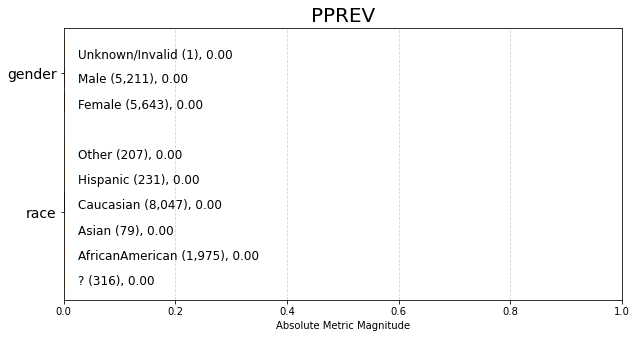

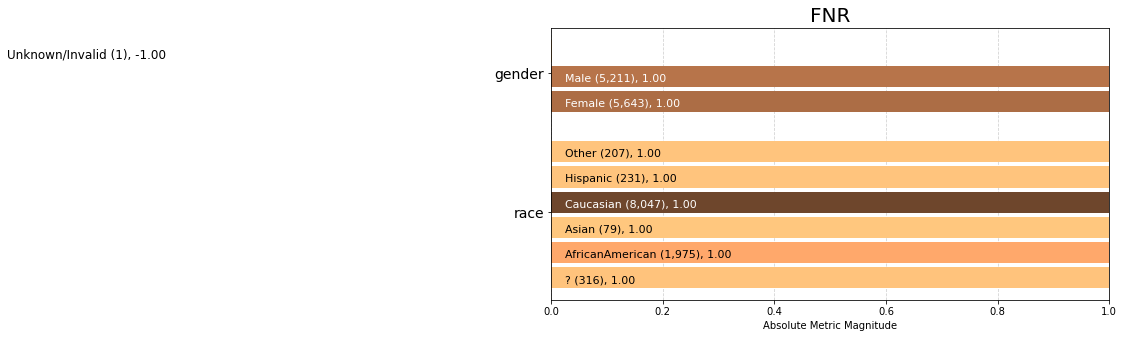

In [157]:
# Plot two metrics

# Plot predicted positive rate by group (race & gender are already in clean_xtab)
aqp.plot_group_metric(clean_xtab, 'pprev', min_group_size=0)

# Plot false negative rate by group
aqp.plot_group_metric(clean_xtab, 'fnr', min_group_size=0)


# Is there significant bias in your model for either race or gender?

##### Bias Analysis – Race and Gender

We analyzed the following metrics across race and gender:

- **False Negative Rate (FNR)**: The rate at which the model fails to predict patients who should be selected.
- **Predicted Positive Rate (PPREV)**: The rate at which the model predicts patients as eligible for drug testing.

#### Observations:

- **FNR is 1.00 for all demographic groups**, meaning the model failed to identify any patients who should be selected for testing. This indicates **complete failure in identifying the positive class**.
- **PPREV is 0.00 for all groups**, meaning **no patients were predicted as eligible**, across all races and genders.

#### Conclusion:

Although the metrics appear equal across groups (suggesting no group is treated worse than another), the model exhibits **complete underperformance** across the board. 

As a result, **all groups are equally excluded**, which is **functionally biased and unusable** for real patient selection.

✅ The next step should be to improve the model’s ability to identify true positives before deeper bias analysis.


## Fairness Analysis Example - Relative to a Reference Group 

**Question 13**: Earlier we defined our reference group and then calculated disparity metrics relative to this grouping. Please provide a visualization of the fairness evaluation for this reference group and analyze whether there is disparity.

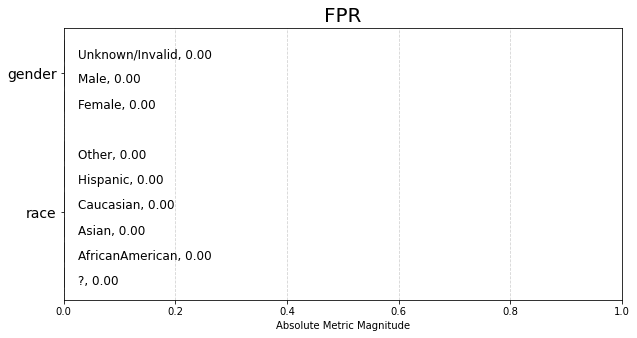

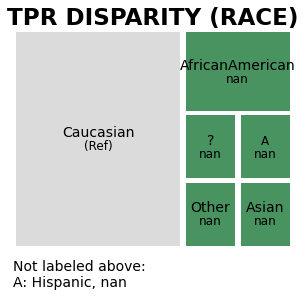

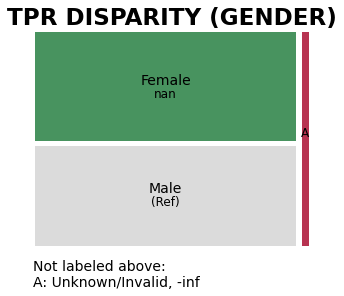

In [161]:
# Fairness plots for the reference group
# Overall FPR fairness across groups
fpr_fairness = aqp.plot_fairness_group(fdf, group_metric='fpr', title=True)

# Disparity in TPR (True Positive Rate) relative to reference group by race
tpr_disparity_race = aqp.plot_fairness_disparity(fdf, group_metric='tpr', attribute_name='race')

# Disparity in TPR relative to reference group by gender
tpr_disparity_gender = aqp.plot_fairness_disparity(fdf, group_metric='tpr', attribute_name='gender')




We defined **Caucasian Males** as our reference group for fairness comparison using the Aequitas toolkit. We visualized disparities using the **True Positive Rate (TPR)** and **False Positive Rate (FPR)**.

---

####  Observations:

- **TPR Disparity (Race & Gender):**  
  All non-reference groups have a TPR of **`nan`**, indicating that the model failed to correctly classify any true positives for *any* group — including the reference group.  
  This makes it impossible to draw meaningful conclusions about fairness **relative** to the reference, since **there are no true positives at all**.

- **FPR Disparity:**  
  All groups showed a False Positive Rate of **0.00**, again suggesting **no positive predictions were made**, regardless of group.

---

#### Interpretation:

There is **no measurable disparity** *between groups* — but only because the model **fails uniformly**. The reference group (Caucasian Males) does not have an advantage or disadvantage, simply because **no group receives a positive prediction** at all.

---

#### Conclusion:

While fairness **disparity appears minimal**, this is due to **total model underperformance**.  
A more effective model is needed before meaningful fairness conclusions can be drawn relative to the reference group.
